# Overview of the tasks to be completed:
## Step 1: combine many messy xls and xlsx files into one, big, clean data structure
 * Step 1.1 convert all files to csv files
 * Step 1.2 clean up these csv files so that they are in a format I can work with
 * Step 1.3 for years that have data spread accross multiple files, combine all that data into a single sheet (i.e., combine all "columns" for a given year)
 * Step 1.4 take data for all years and combine it into one big data structure

Here are my import statements:

In [1]:
import os
import pandas as pd
import csv
import sqlite3
import requests
from functools import reduce
import re
import matplotlib
import math
import numpy as np

I'm copying below the `process_csv` function, which will be useful soon

In [2]:
def process_csv(filename):
    example_file = open(filename, encoding="utf-8")
    example_reader = csv.reader(example_file)
    example_data = list(example_reader)
    example_file.close()
    return example_data

## Step 1.1 convert all files to csv files
The first step will be to import xls and xlsx files using pandas, but before I do that, I need a list of all files in the directory. I'm copying the `get_all_path_in` function from P11, and running it on the folder where all the messy data is stored:

In [3]:
def get_all_paths_in(directory):
    '''get_all_paths_in(directory) recursively 
    explores that directory for any files, 
    and returns a list of paths to 
    files inside that directory'''
    path_list = []
    
    dir_contents = sorted([content for content in os.listdir(directory) if not content.startswith(".")])
    for x in dir_contents:
        path_x = os.path.join(directory, x)
        if os.path.isdir(path_x):
            path_list.extend(get_all_paths_in(path_x))
        elif os.path.isfile(path_x):
            path_list.append(path_x)
        else:
            print("error found")
    path_list.sort()
    return path_list

In [4]:
all_messy_files = get_all_paths_in("MFR Archive")
len(all_messy_files)

106

This list contains some files I don't want: `docx` files, `zip` files, etc. So I'll return a list of only the file paths I want:

In [5]:
select_messy_files = [x for x in all_messy_files if ("xls" in x.lower() or "xlsm" in x.lower())
                        and "Misc" not in x] # I don't know what this misc folder is for, but I don't want it!
len(select_messy_files)

57

Now I'm ready to take all these messy excel files and convert them to csv files. But first I'm writing a function to take messy file path names and make them a little prettier. Note that this could be improved, time permitting

In [6]:
def clean_name(file_path):
    split_path = os.path.split(file_path)
    if "mfr" in split_path[0]:
        mfrx = os.path.split(split_path[0])[1]
        if mfrx[-4:] == split_path[1][0:4]:
            provisional_name = mfrx[:-4] + split_path[1]
        else:
            provisional_name = mfrx + split_path[1]
    elif "super" in split_path[1].lower():
        provisional_name = split_path[1].lower()
    else:
        print("error")
        return
    penultimate_name = "".join(provisional_name.split(".")[:-1])
    final_name = "_".join(penultimate_name.split(" ")) + ".csv"
    return final_name

Using this function, I'll loop through all my file paths and convert them to csv files with nice names. 

In [7]:
if not os.path.exists('csv_files'):
    os.makedirs('csv_files')
    for file in select_messy_files:     
        try:
            temp_df = pd.read_excel(file)
            temp_df.to_csv(os.path.join("csv_files", clean_name(file)), index = False)
        except: # I recognize this is bad practice. There error this threw had a 100-line traceback, and
                # was related to something deep in the pandas module. Manual inspection of the failed files
                # shows that they're both copies of files that already exist, and processed without issue
            print(file, " failed to convert")
else:
    print("There is already a 'csv_files' directory")

There is already a 'csv_files' directory


I'll now make a list of these files...

In [8]:
clean_paths = get_all_paths_in("csv_files")

## Step 1.2 Clean up the csv files so that they are in a format I can work with

In order to leave myself a better trail of breadcrumbs, I'll process the csv files then write the clean files to a new folder called `clean_csvs`. This may be bad coding, and certainly wastes disk space, but in case I make a mistake, it will be nice to not have to reprocess all the excel files again.

### I'll create a function whose input is a messy csv file and output is a clean one. But first, I'll make a helper function that returns the indexes of rows I'm interested in

This helper function will search for the index of the header, the subheader, and first data row
(the header is missing info for a couple columns, so it's useful to also have the subheader)

I'm looking for data first because I want to break the header `for` loop when it reaches the data rows

In [9]:
def get_idxs_headers_and_data(list_of_lists):
    """list of lists a tupple containing the the indexs for:
    the header, the subheader, and the first data row"""
    data_first_row = None
    for row_idx in range(0,len(list_of_lists)):
        if list_of_lists[row_idx][0].isdigit(): # (looking for three rows in a row starting with digits to be extra sure)
            if list_of_lists[row_idx + 1][0].isdigit():
                if list_of_lists[row_idx + 2][0].isdigit():
                    data_first_row = row_idx
                    break
    
    header_list = []
    # first I'll fetch the header
    for row_idx in range(0,data_first_row):
        for cell in list_of_lists[row_idx]:
            if "municipal finance report line" in cell.lower():
                header_list.append(row_idx)
                
    if len(header_list) == 0:
        print("no header found, using row above data")
        header = data_first_row - 1
    elif len(header_list) != 1:
        print("error: multiple 'municipal finance report lines'")
        header = header_list[0]
    else:
        header = header_list[0]
        
    # now I'll fetch the subheader
    subheader_list = []
    if len(header_list) != 0:
        for row_idx in range(0,data_first_row):
            for cell in list_of_lists[row_idx]:
                if "code" in cell.lower():
                    subheader_list.append(row_idx)
                
    if len(subheader_list) == 0:
        subheader = None
    elif len(subheader_list) != 1:
        print("error multiple 'codes'")
        subheader = subheader_list[0]
    else:
        subheader = subheader_list[0]
        

    return (header, subheader, data_first_row)


### now I'll write a function to clean up the header and save a clean csv:
In the header row, I'll replace `''` with the subheader value, remove hyphens, remove alpha prefixes, and make sure alpha suffixes are uppercase. I'll also add a column for year

In [10]:
def make_clean_csv(filepath):
    ''' Takes a csv file with a messy header and writes a cleaned up 
    csv file to folder '''
    # make a clean_csv directory if it doesn't exist already
    if not os.path.exists('clean_csvs'):
        os.makedirs('clean_csvs')
        
    list_of_lists_temp = (process_csv(filepath))
    critical_idxs = get_idxs_headers_and_data(list_of_lists_temp)
    header = list_of_lists_temp[critical_idxs[0]]
 
    if critical_idxs[1] == None:
        subheader = ["code", "municipality", "population"]
    else:
        subheader = list_of_lists_temp[critical_idxs[1]]
    
    # clean up the header
    for idx in range(0, len(header)):
        cell = header[idx]
        if "municipal finance report line" in cell.lower() or cell == "":
            header[idx] = subheader[idx].lower()
        else:    
            if cell != None and cell[1].isdigit():
                cell_list = cell.split("-")
                cell = "".join(cell_list)
                cell_list = cell.split("_")
                cell = "".join(cell_list)

                if cell[-1].isalpha():
                    cell = cell[0:-1] + cell[-1].upper()

                if cell[0].isalpha():
                    header[idx] = cell[1:]
                else:
                    header[idx] = cell
   
    # I've inserted the following code chunk while debugging. The header must include a "code" cell,
    # or else some later operations in pandas won't work
    does_year_column_exist = None
    code_idx = None
    
    for idx in range(0, len(header)):
        cell = header[idx]
        if "code" in cell.lower() and "type" not in cell.lower():
            header[idx] = "code"
            code_idx = idx
        if "municipality" in cell.lower() or "locality" in cell.lower():
            header[idx] = "municipality"            
        if "population" in cell.lower():
            header[idx] = "population"
        if "county" in cell.lower():
            header[idx] = "county"
        if "type" in cell.lower():
            header[idx] = "type"
        if "year" in cell.lower():
            header[idx] = "year"
            does_year_column_exist = "yes"
     
            
        
    # this next chunk makes sure our "code" is actually a code of length 4 or more. In some spreadsheets,
    # codes are spread out accross 3 columns. If the code is less than 4 digits, it checks for this 
    # possibility, and concatenates as appropriate if so. Then it deletes the extra columns
    first_data_row = list_of_lists_temp[critical_idxs[2]]
    
    if len(first_data_row[code_idx]) < 4:
        # this isn't robust, but I'm checking that first characters are digits
        if first_data_row[code_idx + 1][0].isdigit() and first_data_row[code_idx + 2][0].isdigit():
            for row_idx in range(critical_idxs[2],len(list_of_lists_temp)):
                if list_of_lists_temp[row_idx][code_idx] != "":
                    prefix = str(int(float(list_of_lists_temp[row_idx][code_idx])))
                    infix = str(int(float(list_of_lists_temp[row_idx][code_idx + 1])))
                    suffix = str(int(float(list_of_lists_temp[row_idx][code_idx + 2])))
                    if len(suffix) == 1:
                        suffix = "0" + suffix
                    full_code = prefix + infix + suffix
                    list_of_lists_temp[row_idx][code_idx] = full_code
            for row_idx in range(0,len(list_of_lists_temp)):
                list_of_lists_temp[row_idx].pop(code_idx + 1)
                list_of_lists_temp[row_idx].pop(code_idx + 1)       
        else:
            print(first_data_row[code_idx])
            print(first_data_row[code_idx + 1])
            print(first_data_row[code_idx + 2])
            print("file failed to convert. codes are nonstandard: ", filepath)
            return 

    
    # Now we want to populate a year column in the data list
    year = None

    for idx in range(0, len(filepath)):
        if filepath[idx:idx+4].isdigit():
            year = filepath[idx:idx+4]
            break

    assert year != None                  
        
    if does_year_column_exist == None: #don't want to accidentally duplicate this column
        header = ["year"] + header # I want the year stored with each row
        for row_idx in range(critical_idxs[2], len(list_of_lists_temp)):
            list_of_lists_temp[row_idx] = [year] + list_of_lists_temp[row_idx]
    

                
   
    # I wrote this next chunk debug an issue that arose with some tables ending with a "total" row  
    # it searches the last ten rows for "total" in order to trim everything after that
    total_row = None

    for row_idx in range(len(list_of_lists_temp) - 10, len(list_of_lists_temp)):
        for idx in range(0, len(list_of_lists_temp[row_idx])):
            cell = list_of_lists_temp[row_idx][idx]
            if "total" in cell.lower():
                total_row = row_idx
    
    
    with open(os.path.join('clean_csvs', os.path.split(filepath)[-1]), "w", newline="") as f:
        writer = csv.writer(f)
        if total_row != None:
            # I wrote this to debug an issue that arose with some tables ending with a "total row"
            writer.writerows([header] + list_of_lists_temp[critical_idxs[2]:total_row])
        else:
            writer.writerows([header] + list_of_lists_temp[critical_idxs[2]:])
    
    return 

### Using the functions I've written, I'll now loop through all the messy csv files and write clean ones

In [11]:
clean_paths = get_all_paths_in("csv_files") # repasting this code for debugging purposes

if not os.path.exists('clean_csvs'):
    for path in clean_paths:
        try:
            make_clean_csv(path)
        # the following lines are just for debugging the code
        except IndexError:
            print("IndexError with path: ", path)
        except TypeError:
            print("TypeError with path: ", path)
else:
    print("clean_csvs already exists")

no header found, using row above data
no header found, using row above data


To make my life easier, I'll call the `get_all_paths_in` function now

In [13]:
clean_csv_filepaths = get_all_paths_in("clean_csvs")

## Step 1.3 Write a function that, for years that have data spread accross multiple files, combines all that data into a single data structure (i.e., combine all "columns" for a given year)


Now I'll write a function that takes as it's input a year, and returns a dataframe with all files for that year combined. I want to include with all entries the type of locality (village, town, etc) as well as the county it falls on. I have created a mapping file for this based on 2021 classifications. I'll import that now as a dataframe

In [14]:
mapping = pd.read_csv("code_type_county_mapping_2021.csv")

In [69]:
def merge_data_for(year):
    files_x_year = [y for y in clean_csv_filepaths if os.path.split(y)[-1].startswith("mfr") 
                   and os.path.split(y)[-1][3:7] == year]
    if len(files_x_year) == 1:
        merged_df = pd.read_csv(files_x_year[0])
        df_with_map = mapping.merge(merged_df, on=['code'], how = "inner", suffixes = [None, "_duplicate"])
        duplicate_cols = [col for col in merged_df if "duplicate" in col]
        
        final_df = df_with_map.drop(columns = duplicate_cols)
        
        return final_df
    else:
        list_of_dfs = [pd.read_csv(file) for file in files_x_year]
        
        for idx in range(0, len(list_of_dfs)):
            df = list_of_dfs[idx]
            df = df[df['code'].notna()]
            
            df.drop(df[(df['code'] == "*****")|(df['code'] == "XX0XX")|(df['code'] == "XX1XX")|
                       (df['code'] == "XX2XX")| (df['code'] == "XX9XX")|(df['code'] == "")
                      ].index, inplace = True)
            
     ## I want to delete columns with asterisks. I don't understand this code I copied off the internet
            df.columns.str.startswith('**')
            df.loc[:,~df.columns.str.startswith('**')]
            
            df = df.astype({"code": 'Int64', "year": 'Int64'})
           # assert df['code'].notna() == True
            list_of_dfs[idx] = df
            
        merged_df = reduce(lambda x, y: x.merge(y, on=['code', "year"], how = "outer", 
                            suffixes = [None, "_duplicate"]), list_of_dfs) 
        
        df_with_map = mapping.merge(merged_df, on=['code'], how = "inner", suffixes = [None, "_duplicate"])
        duplicate_cols = [col for col in merged_df if "duplicate" in col]
        
        final_df = df_with_map.drop(columns = duplicate_cols)
        return final_df

## Step 1.4 take data for all years and combine it into one big data structure
At long last, it's time to loop through all the years I have data for, and merge all the data into one big dataframe.

First I want to collect a list of the years I'm analyzing. There are two types of files that I'm collecting. "supermfrs" have all data in a single sheet, whereas the others (which I'm calling `multi`) have data spread out accross many sheets. The function above handles these `multi` files.

In [70]:
super_years = []
multi_years = []

for path in clean_csv_filepaths:
    path_tail = os.path.split(path)[-1]
    if path_tail.startswith("super"):
        year = path_tail.split(".")[0][-4:]
        if year not in super_years:
            super_years.append(year)
    elif path_tail.startswith("mfr"):
        year = path_tail[3:7]
        if year not in multi_years:
            multi_years.append(year)
    else:
        print("Error: unrecognized file nameing")
        
all_years = sorted(super_years + multi_years, reverse = True)


Now I'll write a tiny helper function into which I can input a year, and get out dataframe

In [67]:
def get_dataframe_from_year(year):
    if year in super_years:
        df = pd.read_csv([y for y in clean_csv_filepaths if os.path.split(y)[-1].startswith("super") 
                   and os.path.split(y)[-1][-8:-4] == year][0]) # this is not elegant, but it was easy 
        df = df[df['code'].notna()]
        
        df.drop(df[(df['code'] == "*****")|(df['code'] == "XX0XX")|(df['code'] == "XX1XX")|
                   (df['code'] == "XX2XX")|(df['code'] == "XX9XX")|(df['code'] == "nan")
                  ].index, inplace = True)
        
        ## I want to delete columns with asterisks. I don't understand this code I copied off the internet
        df.columns.str.startswith('**')
        df.loc[:,~df.columns.str.startswith('**')]

        df = df.astype({"code": 'Int64', "year": 'Int64'})
        df_with_map = mapping.merge(df, on=['code'], how = "inner", suffixes = [None, "_duplicate"])
        duplicate_cols = [col for col in df_with_map if "duplicate" in col]
        
        final_df = df_with_map.drop(columns = duplicate_cols)
        return final_df
    elif year in multi_years:
        return merge_data_for(year)
    
    

leaving in this line of code for debugging a given year

In [73]:
test_df = get_dataframe_from_year("2001")

And now I'll take all the data and merge it into one big data frame.

In [74]:
list_of_data_frames = []

for year in all_years:
    data_frame_year_x = get_dataframe_from_year(year).astype(str)
    list_of_data_frames.append(data_frame_year_x)

C:\Users\asuiter\AppData\Local\Temp\ipykernel_20080\1888248745.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(df[(df['code'] == "*****")|(df['code'] == "XX0XX")|(df['code'] == "XX1XX")|
C:\Users\asuiter\AppData\Local\Temp\ipykernel_20080\1888248745.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(df[(df['code'] == "*****")|(df['code'] == "XX0XX")|(df['code'] == "XX1XX")|
C:\Users\asuiter\AppData\Local\Temp\ipykernel_20080\1888248745.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/

In [78]:
compiled_data = reduce(lambda x, y: 
                x.merge(y, how = "outer"), list_of_data_frames)

,code,type,county,year,AUTH,municipality,population,00240000,00440000,00540000,...,12455410,12455600,12358211,12358212,12358213,10544110,90050060A.1,90050060B.1,90050060C.1,90050060D.1
0,1002,T,ADAMS,2021,1.0,ADAMS,1365.0,1064712.0,680928.0,7543.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1004,T,ADAMS,2021,2.0,BIG FLATS,1040.0,1008260.0,339928.0,8962.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1006,T,ADAMS,2021,3.0,COLBURN,232.0,529921.0,155945.0,nan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1008,T,ADAMS,2021,4.0,DELL PRAIRIE,1636.0,nan,nan,nan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1010,T,ADAMS,2021,5.0,EASTON,1115.0,707718.0,465930.0,6614.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46081,51014,T,Racine,1998,NaN,Rochester,NaN,NaN,NaN,NaN,...,0,0,0,5160,0,4170,NaN,NaN,NaN,NaN
46082,51018,T,Racine,1998,NaN,Yorkville,NaN,NaN,NaN,NaN,...,0,0,0,0,0,8862,NaN,NaN,NaN,NaN
46083,66020,T,Washington,1998,NaN,Richfield,NaN,NaN,NaN,NaN,...,0,0,0,0,0,38953,NaN,NaN,NaN,NaN
46084,67028,T,Waukesha,1998,NaN,Summit,NaN,NaN,NaN,NaN,...,0,0,0,11984,0,14848,NaN,NaN,NaN,NaN


The next few lines aren't so pretty. I'm just fixing some errors that pop up in the merge

In [80]:
compiled_data['county']=compiled_data['county'].apply(str.upper)
compiled_data['municipality']=compiled_data['municipality'].apply(str.lower).str.strip()

In [81]:
compiled_data = compiled_data[(compiled_data["year"] != "<NA>")]
compiled_data = compiled_data.replace("No report", np.nan)

In [82]:
compiled_data = compiled_data.astype({"code": 'Int64', "year": 'Int64', "population": float, 
                                      "12253610": float, "13057410": float})

My collaborator wants one big csv, so I'll save this data to a csv

In [83]:
compiled_data.to_csv("compiled_data.csv", index = False)

I'm going to send this to a database and work in SQL, just for fun

In [84]:
conn = sqlite3.connect("compiled_data.db")

In [85]:
compiled_data.to_sql("compiled_data", conn, if_exists="replace", index=False)

46086

My collaborator only is interested in a few of the columns right now, so I'll select those for him, then send them to spreadsheet

In [86]:
columns_of_interest = pd.read_sql("""SELECT `year`, `code`, `type`, `county`, `municipality`, `population`, `10041110`, `11147341`,
    `12253610`, `13057410`, `20447341`, `20953610`, `20046410`
    FROM compiled_data
""", conn)
columns_of_interest.head()

,year,code,type,county,municipality,population,10041110,11147341,12253610,13057410,20447341,20953610,20046410
0,2021,1002,T,ADAMS,adams,1365.0,303973,nan,NaN,NaN,nan,nan,nan
1,2021,1004,T,ADAMS,big flats,1040.0,382773,0.0,0.0,0.0,nan,nan,nan
2,2021,1006,T,ADAMS,colburn,232.0,112673,nan,NaN,NaN,nan,nan,nan
3,2021,1008,T,ADAMS,dell prairie,1636.0,267563,0.0,0.0,0.0,nan,nan,nan
4,2021,1010,T,ADAMS,easton,1115.0,256178,nan,NaN,NaN,nan,nan,nan


In [87]:
columns_of_interest.to_csv("columns_of_interest_revised.csv", index = False)

# Some basic questions about the data to answer:
now that I've turned all of these sloppy spreadsheets into one pretty (sort of) data structure, it's time to answer some questions about the data, and make some graphs

Let's first copy some graphing functions over:

In [88]:
def horizontal_bar_plot(df, x, title = None):
    """horizontal_bar_plot(df, x) takes in a DataFrame 'df' and displays 
    a horizontal bar plot with the column 'x' as the x-axis, and all
    other columns of 'df' on the y-axis"""
    df = df.set_index(x)
    ax = df.plot.barh()
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.9))
    ax.set_title(title)

### Question 1: Which municipalities show increasing sewage expenditures and revenues over time?

Using the regression coefficient function from P13, I'll loop through the data and -- for each municipality -- calculate the regression coefficient for spending versus time. If the coefficient is positive, I'll take that to mean that spending is increasing

In [89]:
def get_regression_coeff(df, x, y):
    """get_regression_coeff(df, x, y) takes in a DataFrame 'df' and returns 
    the slope (m) and the y-intercept (b) of the line of best fit in the
    plot with the column 'x' as the x-axis, and the column 'y' as the y-axis"""
    df["1"] = 1
    res = np.linalg.lstsq(df[[x, "1"]], df[y], rcond=None)
    coefficients = res[0]
    m = coefficients[0]
    b = coefficients[1]
    
    return (m, b)

The first issue to address is the fact that not every municipality exists in every year; new municipalities are created, and sometimes municipalities are annexed by teir neighbors. So for the sake of this analysis, I'll just look at municipalities that existed in the most recent year I have data for: 2021.

In [90]:
munis_21 = compiled_data[compiled_data["year"] == 2021]
exist_21 = compiled_data[compiled_data["code"].isin(munis_21["code"])]

Two columns contribute to total sewerage expenditure, so I'll add those two columns, and insert a new series into the data frame

In [91]:
compiled_data["sew_exp"] = compiled_data["12253610"] + compiled_data["13057410"]
compiled_data["time"] = compiled_data["year"] - 1998
compiled_data = compiled_data[["code", "year", "time", "sew_exp", "10041110", "11147341"]]

Now I'll calculate linear regression slopes for each municipality for sewerage expenditure over time. This will be very crude...

In [92]:
list_of_munis = compiled_data[compiled_data["year"] == 2021]["code"]
list(list_of_munis)
muni_coeffs = []
for x in list_of_munis:
    muni_df = compiled_data[compiled_data["code"] == x].astype({"time":float, "11147341":float,
                                                      "10041110":float})
    muni_df = muni_df.dropna()
    reg_coeff = get_regression_coeff(muni_df, x = "time", y="sew_exp" )
    sew_rev_coeff = get_regression_coeff(muni_df, x = "time", y="11147341")
    prop_rev_coeff = get_regression_coeff(muni_df, x = "time", y="10041110")
    muni_coeffs.append((x, reg_coeff, sew_rev_coeff, prop_rev_coeff))
    
increasing_munis = [x for x in muni_coeffs if x[1][0] > 0]
increasing_munis_sorted = sorted(increasing_munis, key = lambda y: y[1][0], reverse = True)

Now I'll find the top 10, recreate a dataframe, and graph!

In [93]:
top_10_increasing_munis = sorted(increasing_munis_sorted[:10], key = lambda y: y[1][0])
top_10_increasing_munis_code = [x[0] for x in top_10_increasing_munis]
top_10_increasing_munis_inc = [x[1][0] for x in top_10_increasing_munis]

d = {"code": top_10_increasing_munis_code, "increase": top_10_increasing_munis_inc}
increase_df = pd.DataFrame(data=d)
increase_df = increase_df.merge(columns_of_interest[columns_of_interest["year"]==2021])[["increase", 
                                                                                         "municipality"]]

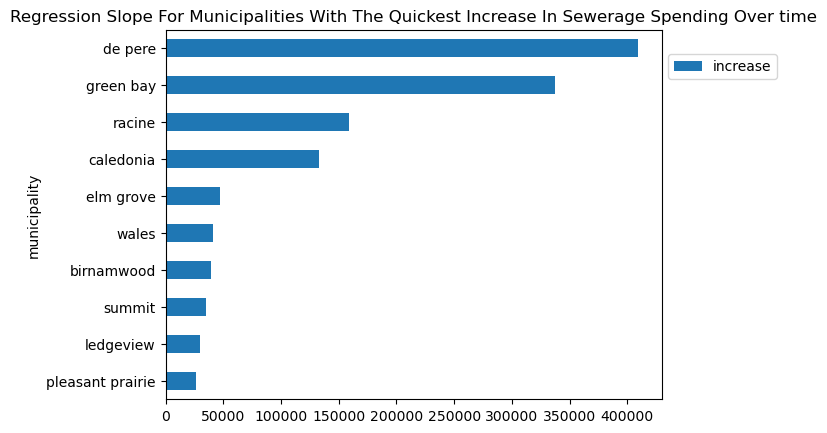

In [94]:
horizontal_bar_plot(increase_df, "municipality", 
title = "Regression Slope For Municipalities With The Quickest Increase In Sewerage Spending Over time")

Just to check whether this are totally crazy or not, I'll make a graph for De Pere

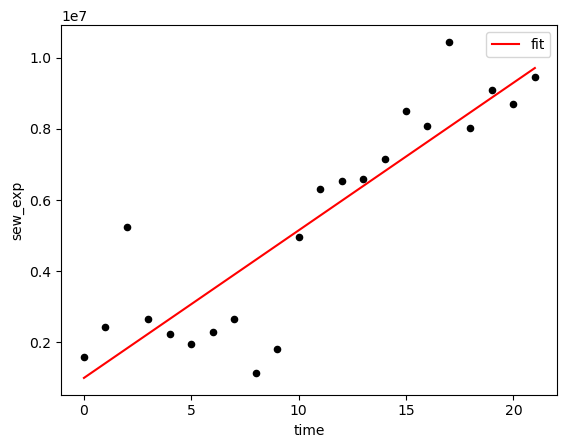

In [129]:
de_pere = compiled_data[(compiled_data['code']== 5216)].dropna().astype({"time":float, "sew_exp":float})

regression_line_plot(de_pere, "time", "sew_exp")

## Question 2: Do property taxes and sewerage revenue increase at comparable rates?


My collaborator wants to know if there is a correlation between property tax increases and sewerage revenue increases. Below is my best attempt, but I don't have the statistical chops necessary to figure this out, so the result is sort of meaningless

I'll copy the needed graphing functions here:

In [95]:
def get_regression_line(df, x, y):
    """get_regression_line(df, x, y) takes in a DataFrame 'df' and returns 
    a DataFrame with an additional column "fit" of the line of best fit in the
    plot with the column 'x' as the x-axis, and the column 'y' as the y-axis"""
    temp_tup = get_regression_coeff(df, x, y)
    m = temp_tup[0]
    b = temp_tup[1]
    
    df['fit'] = m * df[x] + b
    
    return df

In [96]:
def regression_line_plot(df, x, y):
    """regression_line_plot(df, x, y) takes in a DataFrame 'df' and displays
    a scatter plot with the column 'x' as the x-axis, and the column
    'y' as the y-axis, as well as the best fit line for the plot"""
   
    # TODO: use 'get_regression_line' to get the data for the best fit line.
    get_regression_line(df, x, y)
        
    # TODO: use df.plot.scatter (not scatter_plot) to plot the x and y columns
    #       of 'df' in black color.
    ax = df.plot.scatter(x = x, y = y, legend=None, color = 'k')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    
    # TODO: save the return value of df.plot.scatter to a variable called 'ax'
    
    # TODO: use df.plot.line to plot the fitted line in red,
    df.plot.line(x, "fit", color = 'r', ax=ax)

In [97]:
sew_rev_inc = [x[2][0] for x in muni_coeffs]
prop_rev_inc = [x[3][0] for x in muni_coeffs]

d = {"sewage_revenue_inc": sew_rev_inc, "property_tax_inc": prop_rev_inc}
revenue_df = pd.DataFrame(data=d)
revenue_df = revenue_df[(revenue_df["sewage_revenue_inc"] <5000) &
                       (revenue_df["sewage_revenue_inc"] > -5000) &
                        (revenue_df["property_tax_inc"] <5000) &
                        (revenue_df["property_tax_inc"] >-5000)
                       ]

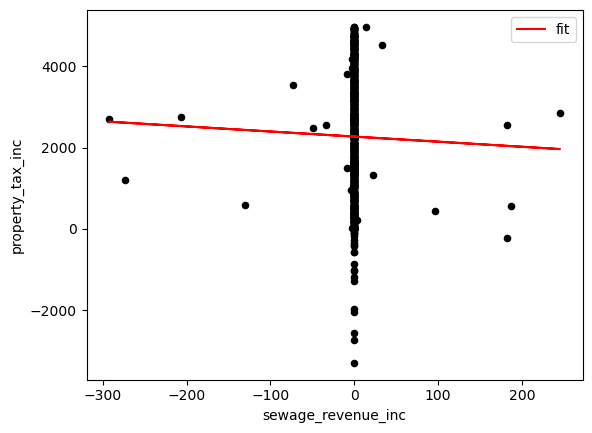

In [98]:
regression_line_plot(revenue_df, "sewage_revenue_inc", "property_tax_inc")

## Question 3: Which municipalities have sewage spending at all?
we'll need a pie plot for this:

Again, I'm doing a very crude analysis. I'll just look at average spending over the entire timeframe I have, and report which municipalities have positive spending. I'll do this in SQL

In [99]:
def pie_plot(df, x, y, title=None):
    """pie_plot(df, x, y, title) takes in a DataFrame 'df' and displays 
    a pie plot with the column 'x' as the x-axis, the (numeric) column
    'y' as the y-axis, and the 'title' as the title of the plot"""
    df = df.set_index(x)
    ax = df.plot.pie(y=y, legend=False)
    ax.set_ylabel(None)
    ax.set_title(title)

In [100]:
munis_with_expenses = pd.read_sql("""SELECT `year`, `code`, `municipality`, `population`, `type`,
AVG(`12253610` + `13057410`) AS avg_sew_expend FROM compiled_data 
GROUP BY `code`
HAVING avg_sew_expend > 0

""", conn)

munis_without_expenses = pd.read_sql("""SELECT `year`, `code`, `municipality`, `population`, `type`,
AVG(`12253610` + `13057410`) AS avg_sew_expend FROM compiled_data 
GROUP BY `code`
HAVING avg_sew_expend == 0

""", conn)


In [101]:
d = {"labels": ["munis_with_expenses", "munis_without_expenses"], 
     "values": [len(munis_with_expenses), len(munis_without_expenses)]}
pie_df = pd.DataFrame(data=d)
pie_df

,labels,values
0,munis_with_expenses,667
1,munis_without_expenses,1271


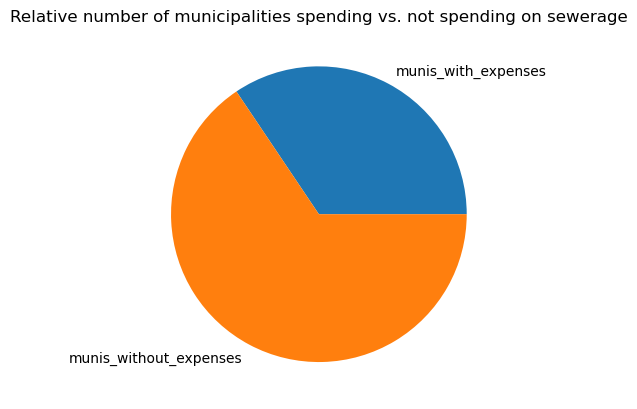

In [102]:
pie_plot(pie_df, "labels",  "values",   
         title = "Relative number of municipalities spending vs. not spending on sewerage")

Notably, only about a third of municipalities have any sewer expenditures

## Question 4: Are larger municipalities are spending more on sewerage?

This is goings to just be a simple regression plot. I'm doing a SQL query and exlcuding outliers Visual inspection suggests that yes, sewerage expenditures rise as populations rise, but it's a very loose correlation

In [103]:
sew_expend = pd.read_sql("""SELECT `year`, `code`, `municipality`, `population`, `type`,
AVG(`12253610` + `13057410`) AS avg_sew_expend FROM compiled_data 
GROUP BY `code`
HAVING avg_sew_expend > 0 and avg_sew_expend <2000000 and population > 0 and population < 90000

""", conn)

sew_expend.head()

,year,code,municipality,population,type,avg_sew_expend
0,2021,1030,rome,2866.0,T,1370.454545
1,2021,1126,friendship,715.0,V,10179.545455
2,2021,1201,adams,1919.0,C,51259.318182
3,2021,2012,jacobs,716.0,T,692.318182
4,2021,2106,butternut,362.0,V,6616.500000


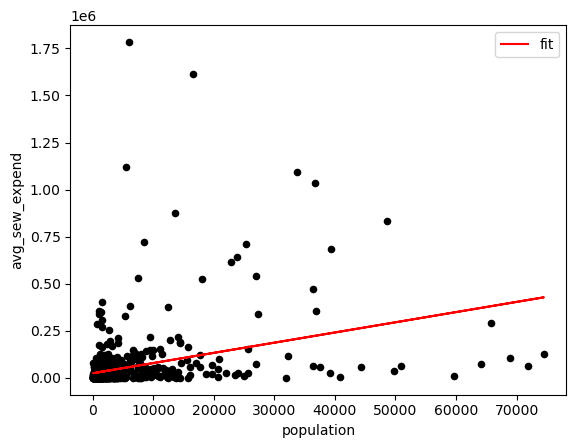

In [55]:
regression_line_plot(sew_expend, 'population', 'avg_sew_expend')

In [130]:
conn.close()